# Music Captioning Pipeline

Generates music descriptions from audio using CLAP similarity matching.

**Steps taken:**
- Pulls descriptors directly from Google's MusicCaps dataset
- Organizes terms by category (genre, mood, instruments, etc.)
- Generates captions via CLAP similarity matching

**Output:** `MUSIC_CAPTION_{video_parent}_{video_name}.txt`

## Setup

In [1]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"  
import gc
import re
import glob
from pathlib import Path
from collections import Counter
import numpy as np
from tqdm import tqdm
import warnings
import subprocess
warnings.filterwarnings('ignore')

import torch
import librosa
import soundfile as sf
from datasets import load_dataset
from transformers import ClapModel, ClapProcessor

# Device setup 
if torch.backends.mps.is_available():
    DEVICE = "mps"
    print("Using MPS (Apple Silicon)")
else:
    DEVICE = "cpu"
    print("Using CPU")

print(f"PyTorch version: {torch.__version__}")

Using MPS (Apple Silicon)
PyTorch version: 2.9.1


## Video to Audio Extraction Functions

In [2]:
def getVideoFilepaths(directories, extensions=None, excluded_paths=None):
    """
    recursively find all video files in directories.
    """
    if extensions is None:
        extensions = ['*.mp4', '*.avi', '*.mov', '*.mkv', '*.flv', '*.wmv', '*.m4v']
    
    if excluded_paths is None:
        excluded_paths = set()
    elif not isinstance(excluded_paths, set):
        excluded_paths = set(excluded_paths)
    
    video_files = []
    for directory in directories:
        for ext in extensions:
            pattern = os.path.join(directory, '**', ext)
            for filepath in glob.glob(pattern, recursive=True):
                if filepath not in excluded_paths:
                    video_files.append(filepath)
            pattern_upper = os.path.join(directory, '**', ext.upper())
            for filepath in glob.glob(pattern_upper, recursive=True):
                if filepath not in excluded_paths:
                    video_files.append(filepath)
    
    return sorted(list(set(video_files)))


def extractAudio(video_path, output_dir, target_sr=48000, max_duration=None):
    """
    extract audio from a video using ffmpeg.
    """
    video_name = Path(video_path).stem
    video_parent = Path(video_path).parent.name
    
    audio_filename = f"{video_parent}_{video_name}.wav"
    audio_path = os.path.join(output_dir, audio_filename)
    
    if os.path.exists(audio_path):
        return audio_path
    
    try:
        cmd = [
            "ffmpeg", "-y",
            "-i", video_path,
            "-vn",
            "-acodec", "pcm_s16le",
            "-ar", str(target_sr),
            "-ac", "1",
        ]
        
        if max_duration:
            cmd.extend(["-t", str(max_duration)])
        
        cmd.append(audio_path)
        
        result = subprocess.run(
            cmd,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL
        )
        
        if result.returncode == 0 and os.path.exists(audio_path):
            return audio_path
        return None
        
    except Exception as e:
        return None


def extractAllAudio(video_dirs, output_dir, excluded_paths=None, max_duration=30.0):
    """
    extract audio from all videos in directories.
    """
    os.makedirs(output_dir, exist_ok=True)
    
    if isinstance(video_dirs, str):
        video_dirs = [video_dirs]
    
    video_files = getVideoFilepaths(video_dirs, excluded_paths=excluded_paths)
    
    successful = 0
    failed = 0
    
    for video_path in tqdm(video_files, desc="extracting audio"):
        audio_path = extractAudio(video_path, output_dir, max_duration=max_duration)
        if audio_path:
            successful += 1
        else:
            failed += 1
        
        if (successful + failed) % 20 == 0:
            gc.collect()
    
    print(f"extracted {successful}/{len(video_files)} audio files")

## Load MusicCaps and Extract Descriptors
- Using to label via CAPS

In [3]:
print("loading musiccaps dataset")
musiccaps = load_dataset("google/MusicCaps", split="train")
print(f"loaded {len(musiccaps)} examples")

Loading MusicCaps dataset
Loaded 5521 examples


In [4]:
def extractDescriptorsFromMusicCaps(dataset, min_frequency=10):
    """
    extract and categorize descriptors from musiccaps captions.
    """
    captions = [example["caption"].lower() for example in dataset]
    all_text = " ".join(captions)
    
    patterns = {
        "genre": [
            r'\b(rock|pop|jazz|blues|classical|electronic|hip hop|hip-hop|rap|'
            r'metal|punk|folk|country|r&b|rnb|soul|funk|disco|reggae|ska|'
            r'ambient|techno|house|trance|dubstep|edm|indie|alternative|'
            r'orchestral|symphonic|opera|choral|gospel|latin|salsa|'
            r'flamenco|celtic|world|new age|lo-fi|lofi|trap|drill|grunge|'
            r'progressive|psychedelic|experimental|industrial|noise|drone|'
            r'soundtrack|cinematic|video game|musical|broadway)\b'
        ],
        "mood": [
            r'\b(happy|sad|melancholic|melancholy|uplifting|energetic|calm|peaceful|'
            r'relaxing|soothing|aggressive|intense|dark|ominous|bright|cheerful|'
            r'dreamy|ethereal|atmospheric|mysterious|eerie|haunting|romantic|'
            r'sensual|nostalgic|bittersweet|hopeful|triumphant|epic|dramatic|'
            r'tense|suspenseful|playful|fun|groovy|funky|mellow|gentle|soft|'
            r'powerful|heavy|light|airy|warm|cold|emotional|passionate|angry|'
            r'joyful|somber|mournful|wistful|longing|serene|tranquil|meditative|'
            r'hypnotic|mesmerizing|upbeat|downtempo|chill|laid-back|laid back)\b'
        ],
        "instruments": [
            r'\b(guitar|acoustic guitar|electric guitar|bass guitar|bass|piano|'
            r'keyboard|synthesizer|synth|organ|drums|drum|percussion|violin|'
            r'viola|cello|double bass|strings|string|orchestra|brass|trumpet|'
            r'trombone|saxophone|sax|flute|clarinet|oboe|french horn|harmonica|'
            r'accordion|banjo|mandolin|ukulele|harp|choir|vocals|voice|singing|'
            r'vocalist|singer|bells|chimes|xylophone|marimba|vibraphone|timpani|'
            r'808|drum machine|pad|arpeggio|lead|bassline)\b'
        ],
        "tempo": [
            r'\b(slow|fast|mid-tempo|midtempo|moderate|uptempo|downtempo|'
            r'steady|driving|pulsing|rhythmic|syncopated|swinging|shuffle|'
            r'four on the floor|4/4|3/4|waltz|march|beat|bpm|tempo|groove|'
            r'breakbeat|arrhythmic|free tempo|rubato)\b'
        ],
        "vocals": [
            r'\b(male vocal|female vocal|male singer|female singer|'
            r'male voice|female voice|man singing|woman singing|'
            r'vocal harmony|harmonies|choir|backing vocal|lead vocal|'
            r'rap|rapping|rapper|spoken word|spoken|singing|sung|'
            r'instrumental|no vocal|without vocal|wordless|humming|'
            r'falsetto|baritone|tenor|soprano|alto|operatic|soulful|'
            r'raspy|breathy|powerful vocal|soft vocal|auto-tune|vocoder)\b'
        ]
    }
    
    def extractTerms(pattern_list, text):
        terms = []
        for pattern in pattern_list:
            matches = re.findall(pattern, text, re.IGNORECASE)
            terms.extend(matches)
        return terms
    
    descriptors = {}
    
    for category, pattern_list in patterns.items():
        terms = extractTerms(pattern_list, all_text)
        term_counts = Counter(terms)
        
        filtered_terms = [
            term.strip().lower()
            for term, count in term_counts.items()
            if count >= min_frequency and len(term.strip()) > 2
        ]
        
        unique_terms = list(set(filtered_terms))
        unique_terms.sort(key=lambda x: term_counts.get(x, 0), reverse=True)
        
        descriptors[category] = unique_terms
    
    return descriptors


DESCRIPTORS = extractDescriptorsFromMusicCaps(musiccaps, min_frequency=10)

print("extracted descriptors:")
for category, terms in DESCRIPTORS.items():
    print(f"  {category}: {len(terms)} terms")
    print(f"    top 5: {terms[:5]}")

Extracted descriptors:
  genre: 48 terms
    Top 5: ['rock', 'pop', 'soundtrack', 'electronic', 'folk']
  mood: 50 terms
    Top 5: ['groovy', 'passionate', 'energetic', 'emotional', 'soft']
  instruments: 49 terms
    Top 5: ['bass', 'singing', 'voice', 'synth', 'guitar']
  tempo: 15 terms
    Top 5: ['tempo', 'beat', 'fast', 'rhythmic', 'slow']
  vocals: 26 terms
    Top 5: ['singing', 'instrumental', 'male voice', 'male vocal', 'female voice']


## Load CLAP Model

In [5]:
print(f"loading clap model on {DEVICE}")

model = ClapModel.from_pretrained("laion/larger_clap_music_and_speech").to(DEVICE)
processor = ClapProcessor.from_pretrained("laion/larger_clap_music_and_speech")

print("model loaded")

Loading CLAP model on mps
CLAP model loaded!


## 6. Pre-compute Text Embeddings

In [6]:
def precomputeTextEmbeddings(descriptors, processor, model, device):
    """
    pre-compute text embeddings for all descriptors.
    """
    embeddings = {}
    
    for category, terms in tqdm(descriptors.items(), desc="computing text embeddings"):
        if not terms:
            continue
        
        text_inputs = processor(
            text=terms,
            return_tensors="pt",
            padding=True
        ).to(device)
        
        with torch.no_grad():
            text_embeds = model.get_text_features(**text_inputs)
            text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)
        
        embeddings[category] = {
            "terms": terms,
            "embeddings": text_embeds
        }
    
    return embeddings


TEXT_EMBEDDINGS = precomputeTextEmbeddings(DESCRIPTORS, processor, model, DEVICE)
print("done")

Pre-computing text embeddings


100%|█████████████████████████████████████████████| 5/5 [00:00<00:00, 21.14it/s]

Done


## Caption Generation

In [7]:
def generateCaption(audio_path, top_k=1):
    """
    generate music caption using clap similarity matching.
    """
    # load audio at 48khz for clap
    waveform, sr = librosa.load(audio_path, sr=48000, mono=True)
    
    # get audio embedding
    inputs = processor(
        audios=waveform,
        sampling_rate=48000,
        return_tensors="pt"
    ).to(DEVICE)
    
    with torch.no_grad():
        audio_embed = model.get_audio_features(**inputs)
        audio_embed = audio_embed / audio_embed.norm(dim=-1, keepdim=True)
    
    # find best matches for each category
    results = {}
    
    for category, data in TEXT_EMBEDDINGS.items():
        similarities = torch.nn.functional.cosine_similarity(
            audio_embed,
            data["embeddings"],
            dim=-1
        )
        
        top_indices = similarities.argsort(descending=True)[:top_k]
        top_terms = [data["terms"][i] for i in top_indices.tolist()]
        top_scores = [similarities[i].item() for i in top_indices]
        
        results[category] = {
            "best": top_terms[0],
            "score": top_scores[0]
        }
    
    return buildCaption(results), results


def buildCaption(results):
    """
    build natural language caption from matching results.
    """
    parts = []
    
    mood = results.get("mood", {}).get("best", "")
    genre = results.get("genre", {}).get("best", "")
    
    if mood and genre:
        parts.append(f"{mood} {genre}")
    elif genre:
        parts.append(genre)
    
    instruments = results.get("instruments", {}).get("best", "")
    if instruments:
        parts.append(f"featuring {instruments}")
    
    tempo = results.get("tempo", {}).get("best", "")
    if tempo:
        parts.append(f"with {tempo}")
    
    vocals = results.get("vocals", {}).get("best", "")
    if vocals and "instrumental" not in vocals.lower() and "no vocal" not in vocals.lower():
        parts.append(f"and {vocals}")
    elif vocals and ("instrumental" in vocals.lower() or "no vocal" in vocals.lower()):
        parts.append("(instrumental)")
    
    caption = " ".join(parts)
    
    if caption:
        caption = caption[0].upper() + caption[1:]
        if not caption.endswith("."):
            caption += "."
    
    return caption

## Batch Processing Function

In [8]:
def generateMusicCaptions(audio_dir, output_dir):
    """
    generate music captions for all audio files.
    """
    os.makedirs(output_dir, exist_ok=True)
    
    audio_files = glob.glob(f"{audio_dir}/*.wav")
    
    if not audio_files:
        print("no audio files found")
        return
    
    successful = 0
    failed = []
    
    for audio_path in tqdm(audio_files, desc="generating captions"):
        try:
            audio_stem = Path(audio_path).stem
            caption_filename = f"MUSIC_CAPTION_{audio_stem}.txt"
            caption_path = os.path.join(output_dir, caption_filename)
            
            if os.path.exists(caption_path):
                successful += 1
                continue
            
            caption, _ = generateCaption(audio_path)
            
            with open(caption_path, 'w', encoding='utf-8') as f:
                f.write(caption)
            
            successful += 1
            
        except Exception as e:
            failed.append((audio_path, str(e)))
            tqdm.write(f"error: {Path(audio_path).name}: {e}")
        
        if successful % 50 == 0:
            gc.collect()
            if DEVICE == "mps":
                torch.mps.empty_cache()
            elif DEVICE == "cuda":
                torch.cuda.empty_cache()
    
    print(f"done: {successful}/{len(audio_files)} successful")
    
    if failed:
        print(f"failed ({len(failed)}):")
        for path, err in failed[:5]:
            print(f"  {Path(path).name}: {err}")

## Execution cells

In [9]:
# paths
VIDEO_DIRS = ["./videos/alt_right_2"]
AUDIO_DIR = "./audio_extracted"
OUTPUT_DIR = "./music_captions"
MAX_AUDIO_DURATION = 30.0

In [10]:
# extract audio
extractAllAudio(
    video_dirs=VIDEO_DIRS, output_dir=AUDIO_DIR,
    excluded_paths=None, max_duration=MAX_AUDIO_DURATION)

Found 942 videos
Starting extraction


Extracting audio: 100%|███████████████████████| 942/942 [00:55<00:00, 17.13it/s]


Extracted 942/942 audio files
Failed: 0
Audio saved to: ./audio_extracted


In [11]:
# generate music captions
generateMusicCaptions(AUDIO_DIR, OUTPUT_DIR)

Found 942 audio files



Generating captions: 100%|████████████████████| 942/942 [00:35<00:00, 26.66it/s]


Done! 942/942 successful
Captions saved to: ./music_captions


## Preview Results

In [12]:
caption_files = glob.glob(f"{OUTPUT_DIR}/MUSIC_CAPTION_*.txt")[:10]

print(f"sample captions ({len(caption_files)} shown):")
for cf in caption_files:
    with open(cf, 'r') as f:
        print(f"{Path(cf).stem}: {f.read()}")

Sample captions (10 shown):

MUSIC_CAPTION_alt_right_2_vril_hyperborea_combovideo-dvce88-20250312155153-7480951307495394578:
  Ominous trance featuring voice with 4/4 and rap.

MUSIC_CAPTION_alt_right_2_alt_right_superfilevideo-meatliciou-20251026153707-7565554805280705806:
  Intense progressive featuring voice with 4/4 and rap.

MUSIC_CAPTION_alt_right_2_alt_right_superfilevideo-kolusola-20250425234847-7497401857942342943:
  Mellow gospel featuring voice with slow and male singer.

MUSIC_CAPTION_alt_right_2_alt_right_superfilevideo-megas_leon-20250605135004-7512462158861438230:
  Aggressive techno featuring lead with uptempo and lead vocal.

MUSIC_CAPTION_alt_right_2_vril_hyperborea_combovideo-daveygrave-20250209225248-7469555958340144430:
  Aggressive techno featuring pad with tempo and rapper.

MUSIC_CAPTION_alt_right_2_vril_hyperborea_combovideo-lukiepukie-20250922000055-7552696757147176222:
  Soothing ambient featuring singing with steady and singing.

MUSIC_CAPTION_alt_right_2_vr

# Idea: Clustering Audio
- I noticed that when I manually looked at the "latin" video, the "rap" video, and the "gospel" video-- they were all non-alt-right edits
- So, can I reliably filter via audio? (In a way, audio being a strong predictor of video belonging makes sense

In [14]:
# IMPORTS FOR CLUSTERING
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from collections import defaultdict
import json
import umap
import hdbscan

In [15]:
def generateAudioEmbeddings(audio_dir, model, processor, device):
    """
    generate clap embeddings for all audio files.
    """
    audio_files = glob.glob(f"{audio_dir}/*.wav")
    
    embeddings_dict = {}
    embeddings_list = []
    video_ids = []
    
    for audio_path in tqdm(audio_files, desc="generating embeddings"):
        try:
            video_id = Path(audio_path).stem
            
            # load audio
            waveform, sr = librosa.load(audio_path, sr=48000, mono=True)
            
            # get embedding
            inputs = processor(
                audios=waveform,
                sampling_rate=48000,
                return_tensors="pt"
            ).to(device)
            
            with torch.no_grad():
                embedding = model.get_audio_features(**inputs)
                embedding = embedding / embedding.norm(dim=-1, keepdim=True)
                embedding = embedding.cpu().numpy().flatten()
            
            embeddings_dict[video_id] = embedding
            embeddings_list.append(embedding)
            video_ids.append(video_id)
            
        except Exception as e:
            print(f"error processing {audio_path}: {e}")
    
    embeddings_matrix = np.array(embeddings_list)
    print(f"generated {len(embeddings_dict)} embeddings, shape: {embeddings_matrix.shape}")
    
    return embeddings_dict, embeddings_matrix, video_ids

In [16]:
EMBEDDINGS_DICT, EMBEDDINGS_MATRIX, VIDEO_IDS = generateAudioEmbeddings(
    AUDIO_DIR, model, processor, DEVICE)

Generating embeddings for 942 audio files...



Generating embeddings: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 942/942 [00:35<00:00, 26.42it/s]


Generated 942 embeddings
Embedding shape: (942, 512)


## Clustering funcs

In [19]:
def clusterEmbeddings(embeddings_matrix, method="hdbscan", n_clusters=10, min_cluster_size=5):
    """
    cluster audio embeddings.
    """
    # normalize embeddings
    scaler = StandardScaler()
    embeddings_scaled = scaler.fit_transform(embeddings_matrix)
    
    if method == "hdbscan":
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=3,
            metric='euclidean',
            cluster_selection_method='eom'
        )
        labels = clusterer.fit_predict(embeddings_scaled)
    else:
        clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        labels = clusterer.fit_predict(embeddings_scaled)
    
    unique_labels = set(labels)
    n_clusters_found = len(unique_labels) - (1 if -1 in unique_labels else 0)
    n_noise = list(labels).count(-1)
    
    print(f"found {n_clusters_found} clusters")
    if n_noise > 0:
        print(f"noise points: {n_noise}")
    
    print("cluster sizes:")
    for label in sorted(unique_labels):
        if label == -1:
            continue
        count = list(labels).count(label)
        print(f"  cluster {label}: {count} videos")
    
    return labels, clusterer

In [22]:
CLUSTER_LABELS, CLUSTERER = clusterEmbeddings(
    EMBEDDINGS_MATRIX, method="kmeans", n_clusters=2, min_cluster_size=5)

Clustering 942 embeddings using kmeans
Found 2 clusters

Cluster sizes:
  Cluster 0: 421 videos
  Cluster 1: 521 videos


In [25]:
def reduceForVisualization(embeddings_matrix, method="umap"):
    """
    reduce embeddings to 2d for visualization.
    """
    if method == "umap":
        reducer = umap.UMAP(
            n_components=2,
            n_neighbors=15,
            min_dist=0.1,
            metric='cosine',
            random_state=42
        )
        embeddings_2d = reducer.fit_transform(embeddings_matrix)
    else:
        from sklearn.decomposition import PCA
        reducer = PCA(n_components=2, random_state=42)
        embeddings_2d = reducer.fit_transform(embeddings_matrix)
    
    print(f"reduced to shape: {embeddings_2d.shape}")
    return embeddings_2d

In [26]:
EMBEDDINGS_2D = reduceForVisualization(EMBEDDINGS_MATRIX, method="umap")

Reducing dimensions using umap
Reduced to shape: (942, 2)


## VIZ FUNC

In [27]:
def plotClusters(embeddings_2d, labels, video_ids=None, title="audio embedding clusters"):
    """
    plot clustered embeddings.
    """
    fig, ax = plt.subplots(figsize=(14, 10))
    
    unique_labels = sorted(set(labels))
    n_colors = len(unique_labels)
    
    if -1 in unique_labels:
        colors = ['#CCCCCC'] + list(sns.color_palette("husl", n_colors - 1))
        label_to_color = {label: colors[i] for i, label in enumerate(unique_labels)}
    else:
        colors = sns.color_palette("husl", n_colors)
        label_to_color = {label: colors[i] for i, label in enumerate(unique_labels)}
    
    for label in unique_labels:
        mask = labels == label
        cluster_name = f"cluster {label}" if label != -1 else "noise"
        
        ax.scatter(
            embeddings_2d[mask, 0],
            embeddings_2d[mask, 1],
            c=[label_to_color[label]],
            label=cluster_name,
            alpha=0.7,
            s=50
        )
    
    ax.set_xlabel("umap 1")
    ax.set_ylabel("umap 2")
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

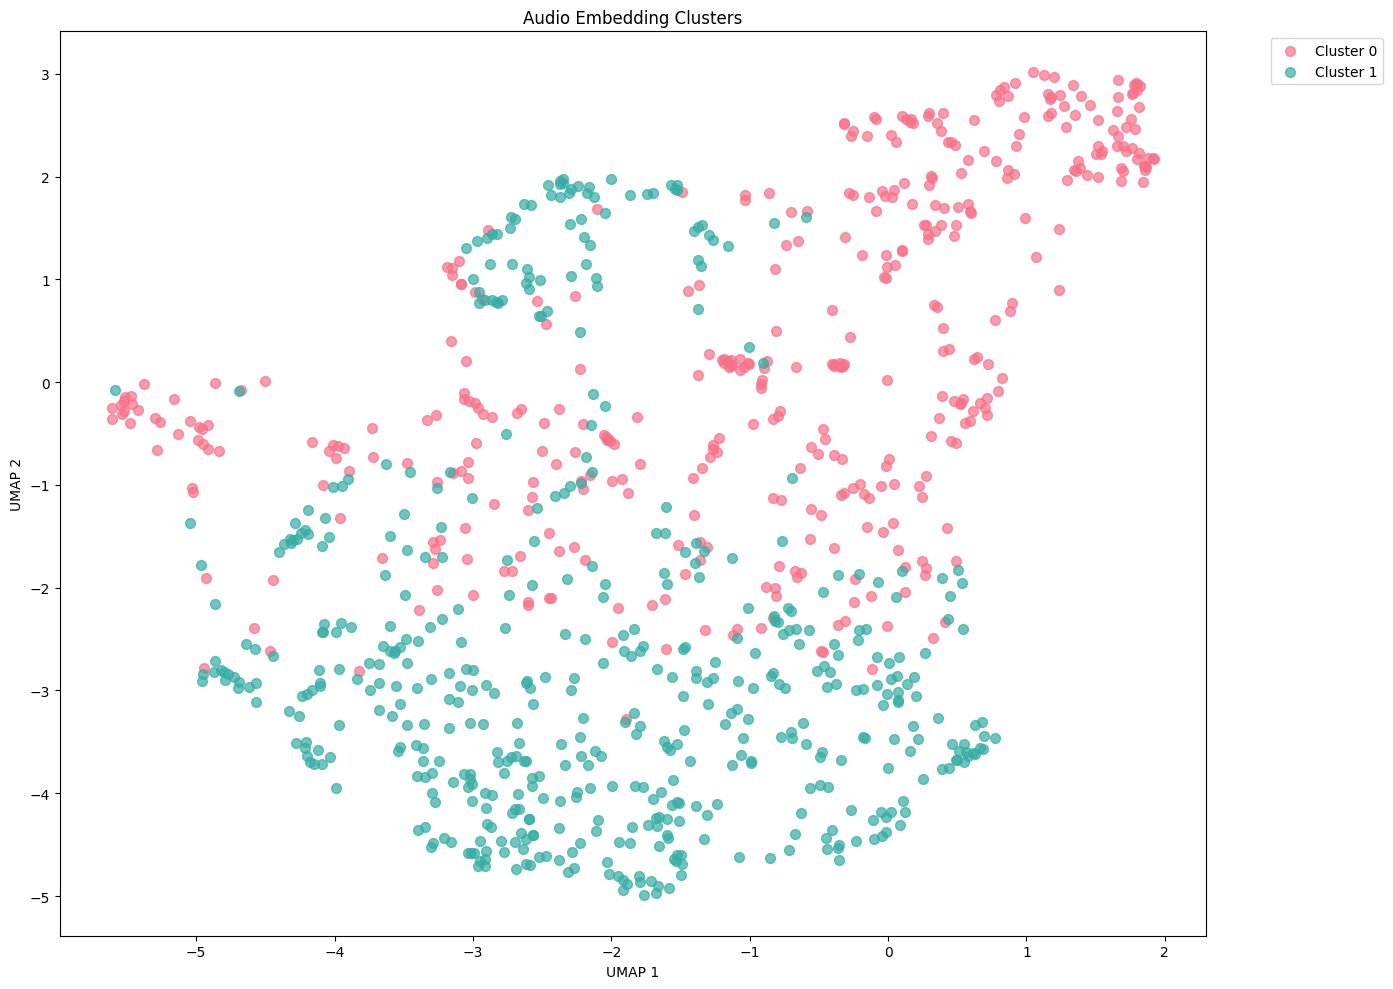

In [28]:
plotClusters(EMBEDDINGS_2D, CLUSTER_LABELS, VIDEO_IDS)

In [29]:
def loadCaptionsForAnalysis(caption_dir, video_ids, cluster_labels):
    """
    load captions and create analysis dataframe.
    """
    data = []
    
    for video_id, label in zip(video_ids, cluster_labels):
        caption_path = os.path.join(caption_dir, f"MUSIC_CAPTION_{video_id}.txt")
        
        caption = ""
        if os.path.exists(caption_path):
            with open(caption_path, 'r') as f:
                caption = f.read().strip()
        
        data.append({
            "video_id": video_id,
            "cluster": label,
            "caption": caption
        })
    
    df = pd.DataFrame(data)
    print(f"loaded {len(df)} videos with captions")
    print(f"videos per cluster:\n{df['cluster'].value_counts().sort_index()}")
    
    return df

In [30]:
DF_ANALYSIS = loadCaptionsForAnalysis(OUTPUT_DIR, VIDEO_IDS, CLUSTER_LABELS)
DF_ANALYSIS.head(10)

Loaded 942 videos with captions
Videos per cluster:
cluster
0    421
1    521
Name: count, dtype: int64


,video_id,cluster,caption
0,alt_right_2_alt_right_superfilevideo-countdown...,0,Ominous video game featuring pad with slow and...
1,alt_right_2_alt_right_superfilevideo-stickz404...,1,Powerful trance featuring pad with 4/4 and lea...
2,alt_right_2_vril_hyperborea_combovideo-eskuank...,1,Playful punk featuring pad with 4/4 and lead v...
3,alt_right_2_alt_right_superfilevideo-agarthagi...,0,Eerie industrial featuring pad with groove and...
4,alt_right_2_alt_right_superfilevideo-4noif-202...,0,Hypnotic techno featuring pad with groove and ...
5,alt_right_2_vril_hyperborea_combovideo-shadow_...,1,Playful video game featuring pad with 4/4 and ...
6,alt_right_2_alt_right_superfilevideo-ossetian_...,1,Eerie trance featuring lead with uptempo and l...
7,alt_right_2_vril_hyperborea_combovideo-deezmas...,0,Intense progressive featuring voice with 4/4 a...
8,alt_right_2_alt_right_superfilevideo-romanian_...,1,Playful techno featuring pad with beat and sung.
9,alt_right_2_alt_right_superfilevideo-jj12265-2...,1,Ominous experimental featuring pad with tempo ...


In [31]:
def analyzeClusterTerms(df, top_n=10):
    """
    find distinctive terms for each cluster using c-tf-idf approach.
    """
    df_clean = df[df['cluster'] != -1].copy()
    
    # concatenate captions per cluster
    cluster_docs = df_clean.groupby('cluster')['caption'].apply(' '.join).reset_index()
    cluster_docs.columns = ['cluster', 'text']
    
    # compute tf-idf across cluster documents
    vectorizer = TfidfVectorizer(
        max_features=500,
        stop_words='english',
        ngram_range=(1, 2),
        min_df=1
    )
    
    tfidf_matrix = vectorizer.fit_transform(cluster_docs['text'])
    feature_names = vectorizer.get_feature_names_out()
    
    cluster_terms = {}
    
    print("=" * 60)
    print("top distinctive terms per cluster (c-tf-idf)")
    print("=" * 60)
    
    for idx, row in cluster_docs.iterrows():
        cluster_id = row['cluster']
        tfidf_scores = tfidf_matrix[idx].toarray().flatten()
        
        top_indices = tfidf_scores.argsort()[-top_n:][::-1]
        top_terms = [(feature_names[i], tfidf_scores[i]) for i in top_indices]
        
        cluster_terms[cluster_id] = top_terms
        
        n_videos = len(df_clean[df_clean['cluster'] == cluster_id])
        print(f"\ncluster {cluster_id} ({n_videos} videos):")
        print("-" * 40)
        for term, score in top_terms:
            print(f"  {term:25s} {score:.3f}")
    
    return cluster_terms

In [32]:
CLUSTER_TERMS = analyzeClusterTerms(DF_ANALYSIS, top_n=10)

TOP DISTINCTIVE TERMS PER CLUSTER (c-TF-IDF)

Cluster 0 (421 videos):
----------------------------------------
  featuring                 0.674
  rap                       0.343
  featuring pad             0.214
  pad                       0.214
  singer                    0.194
  voice                     0.182
  featuring voice           0.168
  ominous                   0.107
  steady                    0.101
  male                      0.101

Cluster 1 (521 videos):
----------------------------------------
  featuring                 0.530
  lead                      0.338
  pad                       0.319
  featuring pad             0.319
  rap                       0.203
  lead vocal                0.194
  vocal                     0.194
  trance featuring          0.179
  trance                    0.179
  playful                   0.157


In [33]:
def computeLogOdds(df, smoothing=0.5):
    """
    compute log-odds ratio for terms in each cluster vs all others.
    """
    from collections import Counter
    import math
    
    df_clean = df[df['cluster'] != -1].copy()
    clusters = sorted(df_clean['cluster'].unique())
    
    def tokenize(text):
        text = text.lower()
        text = re.sub(r'[^\w\s]', '', text)
        return text.split()
    
    df_clean['tokens'] = df_clean['caption'].apply(tokenize)
    
    # count terms per cluster
    cluster_term_counts = {}
    cluster_total_terms = {}
    
    for cluster in clusters:
        cluster_captions = df_clean[df_clean['cluster'] == cluster]['tokens']
        all_tokens = [t for tokens in cluster_captions for t in tokens]
        cluster_term_counts[cluster] = Counter(all_tokens)
        cluster_total_terms[cluster] = len(all_tokens)
    
    # global counts
    all_tokens = [t for tokens in df_clean['tokens'] for t in tokens]
    global_counts = Counter(all_tokens)
    global_total = len(all_tokens)
    
    print("=" * 60)
    print("log-odds ratio: distinctive terms per cluster")
    print("(higher = more distinctive to this cluster)")
    print("=" * 60)
    
    cluster_log_odds = {}
    
    for cluster in clusters:
        log_odds = {}
        n_cluster = cluster_total_terms[cluster]
        n_other = global_total - n_cluster
        
        for term, count in cluster_term_counts[cluster].items():
            if global_counts[term] < 3:
                continue
            
            count_cluster = count + smoothing
            count_other = (global_counts[term] - count) + smoothing
            
            odds_cluster = count_cluster / (n_cluster - count_cluster + smoothing)
            odds_other = count_other / (n_other - count_other + smoothing)
            
            log_odds[term] = math.log(odds_cluster / odds_other)
        
        sorted_terms = sorted(log_odds.items(), key=lambda x: x[1], reverse=True)
        cluster_log_odds[cluster] = sorted_terms[:15]
        
        n_videos = len(df_clean[df_clean['cluster'] == cluster])
        print(f"\ncluster {cluster} ({n_videos} videos):")
        print("-" * 40)
        for term, score in sorted_terms[:10]:
            print(f"  {term:25s} {score:+.2f}")
    
    return cluster_log_odds

In [34]:
CLUSTER_LOG_ODDS = computeLogOdds(DF_ANALYSIS)

LOG-ODDS RATIO: DISTINCTIVE TERMS PER CLUSTER
(Higher = more distinctive to this cluster)

Cluster 0 (421 videos):
----------------------------------------
  vocals                    +3.95
  hiphop                    +3.85
  gospel                    +3.79
  ambient                   +3.79
  humming                   +3.67
  synthesizer               +3.37
  peaceful                  +3.37
  alto                      +3.28
  mellow                    +3.28
  soothing                  +3.18

Cluster 1 (521 videos):
----------------------------------------
  dubstep                   +3.07
  vocal                     +2.09
  bright                    +2.05
  aggressive                +1.83
  uptempo                   +1.63
  instrumental              +1.61
  lead                      +1.57
  eerie                     +1.46
  pop                       +1.44
  trance                    +1.40
